# Lab 2: Decision Tree with K-Fold CV
In this notebook, we load the preprocessed Titanic dataset, implement a Decision Tree Classifier,
perform 10-fold cross-validation, and visualize the tree.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import cross_val_score, KFold

## 1. Load Processed Data

In [ ]:
df = pd.read_csv('data/titanic_processed.csv')
print(f"Data shape: {df.shape}")
df.head()

# Drop 'Name' if it exists since it's a string identifier
if 'Name' in df.columns:
    df = df.drop(columns=['Name'])

X = df.drop(columns=['Survived'])
y = df['Survived']

Data shape: (891, 10)


## 2. Implement Decision Tree Classifier and 10-Fold CV

In [ ]:
# Setting a modest max_depth to keep the visualization readable
dt = DecisionTreeClassifier(random_state=42, max_depth=3)

# 10-fold CV
kf = KFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_val_score(dt, X, y, cv=kf, scoring='accuracy')

print(f"10-Fold CV Accuracy Scores: {np.round(scores, 4)}")
print(f"Average Accuracy: {np.mean(scores):.4f}")
print(f"Standard Deviation: {np.std(scores):.4f}")

10-Fold CV Accuracy Scores: [0.8222 0.7753 0.8539 0.7528 0.8539 0.8764 0.7753 0.7865 0.7753 0.8764]
Average Accuracy: 0.8148
Standard Deviation: 0.0448


## 3. Visualize the Decision Tree

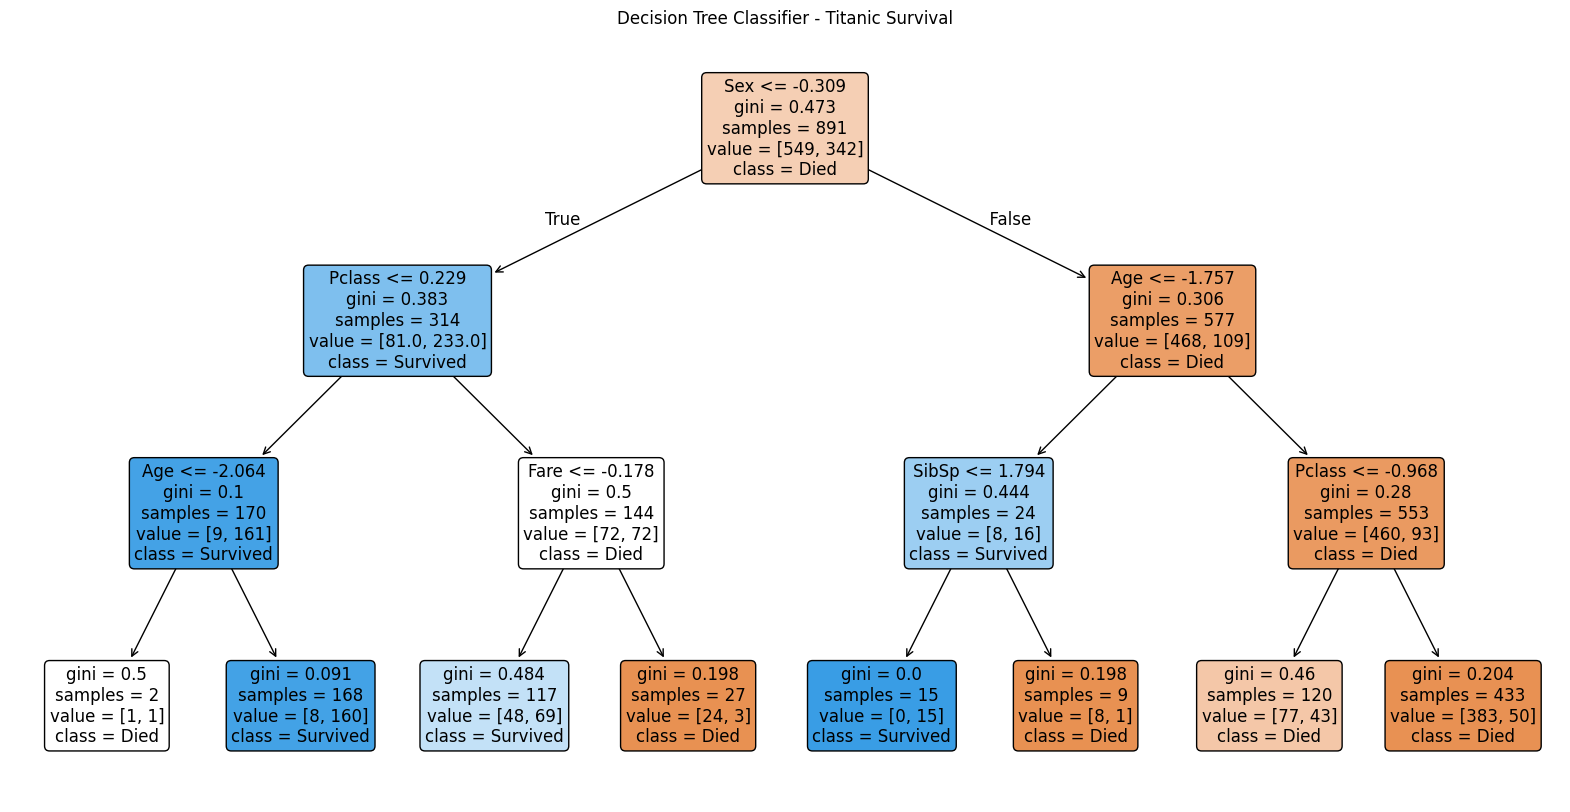

Tree visualization rendered and saved to decision_tree_visualization.png


In [ ]:
# Fit on the entire dataset for visualization
dt.fit(X, y)

plt.figure(figsize=(20,10))
plot_tree(dt, feature_names=X.columns.tolist(), class_names=['Died', 'Survived'], filled=True, rounded=True, fontsize=12)
plt.title("Decision Tree Classifier - Titanic Survival")
plt.savefig('decision_tree_visualization.png')
plt.show()
print("Tree visualization rendered and saved to decision_tree_visualization.png")